In [1]:
# Importing necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, mean_absolute_error,
                              mean_squared_error, r2_score)
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')


In [2]:
# Load from saved files
df_clean = pd.read_csv("data/processed/analysis_ready.csv")
print(df_clean.shape)

(7412, 15)


In [3]:
# Schema Validation — Final analysis_ready.csv
print("=" * 60)
print("      SCHEMA VALIDATION — analysis_ready.csv")
print("=" * 60)

schema = pd.DataFrame({
    'Column': df_clean.columns,
    'Dtype': df_clean.dtypes.values,
    'Non_Null': df_clean.notnull().sum().values,
    'Null': df_clean.isnull().sum().values,
    'Null_%': (df_clean.isnull().sum().values / len(df_clean) * 100).round(2),
    'Sample_Value': [df_clean[col].dropna().iloc[0] if df_clean[col].notna().any() else 'N/A' for col in df_clean.columns]
})

# Display the schema validation results

print(schema.to_string(index=False))
print("=" * 60)
print(f"Total columns : {len(df_clean.columns)}")
print(f"Total rows    : {len(df_clean):,}")
print(f"Zero nulls    : {df_clean.isnull().sum().sum() == 0}")

      SCHEMA VALIDATION — analysis_ready.csv
                  Column   Dtype  Non_Null  Null  Null_% Sample_Value
                 country     str      7412     0     0.0  Afghanistan
            country_code     str      7412     0     0.0          AFG
                    year   int64      7412     0     0.0         1990
      electricity_access float64      7412     0     0.0          4.4
          gdp_per_capita float64      7412     0     0.0   174.930991
urban_population_percent float64      7412     0     0.0    17.264035
rural_population_percent float64      7412     0     0.0    82.735965
      population_density float64      7412     0     0.0    18.468424
        total_population float64      7412     0     0.0   12045660.0
renewable_energy_percent float64      7412     0     0.0         23.0
government_effectiveness float64      7412     0     0.0    -2.175167
           risk_category     str      7412     0     0.0       Severe
      elec_access_change float64      7412   

# Train / Validation / Test Split

In [4]:
# Final check on year range and country coverage before modeling

print("=== Filter to 1990–2023 ===\n")

df_model = df_clean[
    (df_clean['year'] >= 1990) & (df_clean['year'] <= 2023)
].copy().reset_index(drop=True)

# Summary of dataset after filtering for modeling

print(f"Original shape : {df_clean.shape}")
print(f"Filtered shape : {df_model.shape}")
print(f"Year range     : {int(df_model['year'].min())}–{int(df_model['year'].max())}")
print(f"Countries      : {df_model['country'].nunique()}")

=== Filter to 1990–2023 ===

Original shape : (7412, 15)
Filtered shape : (7412, 15)
Year range     : 1990–2023
Countries      : 218


In [5]:
#  80/10/10 Temporal Split 
# Train    : 1990–2017  (~80%) — model learns from historical data
# Validate : 2018–2020  (~10%) — tune model hyperparameters
# Test     : 2021–2023  (~10%) — final accuracy check, simulate forecast
# Forecast : 2024–2027         — true future, no actuals available yet

train_df = df_model[df_model['year'] <= 2017].copy().reset_index(drop=True)
val_df   = df_model[(df_model['year'] >= 2018) & (df_model['year'] <= 2020)].copy().reset_index(drop=True)
test_df  = df_model[df_model['year'] >= 2021].copy().reset_index(drop=True)

# Summary of temporal split

print("=== 80/10/10 Temporal Split ===\n")
print(f"{'Set':<12} {'Years':<15} {'Rows':>8} {'%':>8}")
print("-" * 45)
print(f"{'Train':<12} {'1990–2017':<15} {len(train_df):>8,} {len(train_df)/len(df_model)*100:>7.1f}%")
print(f"{'Validate':<12} {'2018–2020':<15} {len(val_df):>8,} {len(val_df)/len(df_model)*100:>7.1f}%")
print(f"{'Test':<12} {'2021–2023':<15} {len(test_df):>8,} {len(test_df)/len(df_model)*100:>7.1f}%")
print("-" * 45)
print(f"{'Total':<12} {'1990–2023':<15} {len(df_model):>8,} {'100.0%':>8}")
print(f"\nForecast target : 2024–2027 (true future, no actuals available)")

=== 80/10/10 Temporal Split ===

Set          Years               Rows        %
---------------------------------------------
Train        1990–2017          6,104    82.4%
Validate     2018–2020            654     8.8%
Test         2021–2023            654     8.8%
---------------------------------------------
Total        1990–2023          7,412   100.0%

Forecast target : 2024–2027 (true future, no actuals available)


In [6]:
# Check class balance across sets to ensure no major distribution shifts

print("=== Class Balance Across All Three Sets ===\n")

order = ['Severe', 'Moderate', 'Minimal']

# Calculate counts and percentages for each category in train, val, and test sets, then print in a formatted table

print(f"{'Category':<12} {'Train':>8} {'Train%':>8} {'Val':>8} {'Val%':>8} {'Test':>8} {'Test%':>8}")
print("-" * 65)

for cat in order:
    tc = train_df['risk_category'].value_counts().get(cat, 0)
    tp = train_df['risk_category'].value_counts(normalize=True).get(cat, 0) * 100
    vc = val_df['risk_category'].value_counts().get(cat, 0)
    vp = val_df['risk_category'].value_counts(normalize=True).get(cat, 0) * 100
    sc = test_df['risk_category'].value_counts().get(cat, 0)
    sp = test_df['risk_category'].value_counts(normalize=True).get(cat, 0) * 100
    print(f"  {cat:<10} {tc:>8,} {tp:>7.1f}% {vc:>8,} {vp:>7.1f}% {sc:>8,} {sp:>7.1f}%")

print("-" * 65)
print(f"  {'Total':<10} {len(train_df):>8,} {'100.0%':>8} {len(val_df):>8,} {'100.0%':>8} {len(test_df):>8,} {'100.0%':>8}")

=== Class Balance Across All Three Sets ===

Category        Train   Train%      Val     Val%     Test    Test%
-----------------------------------------------------------------
  Severe        1,386    22.7%       85    13.0%       63     9.6%
  Moderate      1,057    17.3%       95    14.5%      112    17.1%
  Minimal       3,661    60.0%      474    72.5%      479    73.2%
-----------------------------------------------------------------
  Total         6,104   100.0%      654   100.0%      654   100.0%


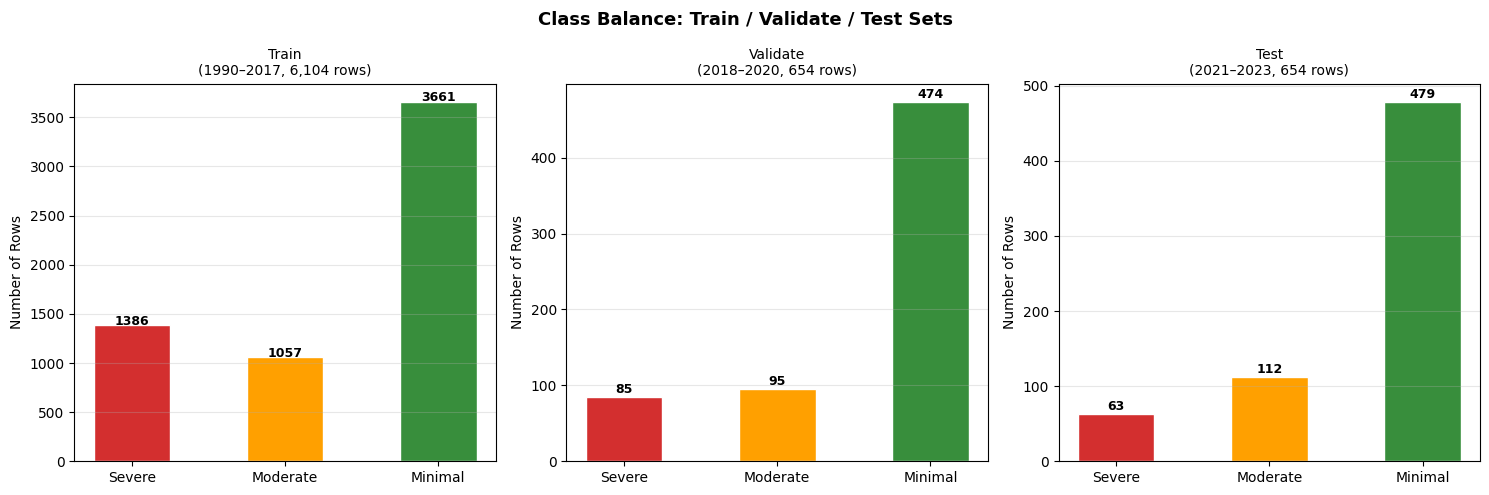

In [7]:
# Visualize class balance across sets

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Class Balance: Train / Validate / Test Sets",
             fontsize=13, fontweight='bold')

colors   = ['#D32F2F', '#FFA000', '#388E3C']
datasets = [
    (train_df, f"Train\n(1990–2017, {len(train_df):,} rows)"),
    (val_df,   f"Validate\n(2018–2020, {len(val_df):,} rows)"),
    (test_df,  f"Test\n(2021–2023, {len(test_df):,} rows)"),
]

for ax, (data, title) in zip(axes, datasets):
    counts = data['risk_category'].value_counts()
    vals   = [counts.get(c, 0) for c in order]
    bars   = ax.bar(order, vals, color=colors, edgecolor='white', width=0.5)
    ax.set_title(title, fontsize=10)
    ax.set_ylabel("Number of Rows")
    ax.grid(True, axis='y', alpha=0.3)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 5,
                str(v), ha='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

In [8]:
# Verify No overlap of years between sets

print("=== Split Integrity Check ===\n")

train_years = set(train_df['year'].unique())
val_years   = set(val_df['year'].unique())
test_years  = set(test_df['year'].unique())

# Print year ranges for each set

print(f"Train years    : {min(train_years)}–{max(train_years)}")
print(f"Validate years : {min(val_years)}–{max(val_years)}")
print(f"Test years     : {min(test_years)}–{max(test_years)}")

# Check for any overlap in years between sets

overlap_tv = train_years & val_years
overlap_vt = val_years   & test_years
overlap_tt = train_years & test_years

# Print overlap results

print(f"\nTrain ∩ Validate : {overlap_tv}  (should be empty)")
print(f"Validate ∩ Test  : {overlap_vt}  (should be empty)")
print(f"Train ∩ Test     : {overlap_tt}  (should be empty)")

# Final sanity check on total row counts across splits vs original filtered dataset

total_check = len(train_df) + len(val_df) + len(test_df)
print(f"\nTrain + Val + Test : {total_check:,}")
print(f"Total df_model     : {len(df_model):,}")
print(f"Counts match       : {total_check == len(df_model)}")

# Print final integrity check message

print("\nNo overlap between any sets." if not overlap_tv and not overlap_vt and not overlap_tt
      else "\nOverlap detected — check split logic.")

=== Split Integrity Check ===

Train years    : 1990–2017
Validate years : 2018–2020
Test years     : 2021–2023

Train ∩ Validate : set()  (should be empty)
Validate ∩ Test  : set()  (should be empty)
Train ∩ Test     : set()  (should be empty)

Train + Val + Test : 7,412
Total df_model     : 7,412
Counts match       : True

No overlap between any sets.


In [9]:
# Save the three sets to CSV files for modeling

os.makedirs("data/processed", exist_ok=True)

train_df.to_csv("data/processed/train_data.csv",      index=False)
val_df.to_csv("data/processed/validation_data.csv",   index=False)
test_df.to_csv("data/processed/test_data.csv",        index=False)

# Final summary of saved files

print("=== Files Saved to data/processed/ ===\n")
print(f"train_data.csv      : 1990–2017  {len(train_df):,} rows  ({len(train_df)/len(df_clean)*100:.1f}%)")
print(f"validation_data.csv : 2018–2020  {len(val_df):,} rows    ({len(val_df)/len(df_clean)*100:.1f}%)")
print(f"test_data.csv       : 2021–2023  {len(test_df):,} rows    ({len(test_df)/len(df_clean)*100:.1f}%)")

=== Files Saved to data/processed/ ===

train_data.csv      : 1990–2017  6,104 rows  (82.4%)
validation_data.csv : 2018–2020  654 rows    (8.8%)
test_data.csv       : 2021–2023  654 rows    (8.8%)


## Modelling

In [10]:
# Features used for both classification and regression

FEATURES = [
    'gdp_per_capita',
    'urban_population_percent',
    'rural_population_percent',
    'population_density',
    'total_population',
    'renewable_energy_percent',
    'government_effectiveness',
    'elec_access_change',
    'gdp_growth',
    'urban_change'
]

CLASS_TARGET = 'risk_category'
REG_TARGET   = 'electricity_access'

# Encode class labels
le = LabelEncoder()
le.fit(['Severe', 'Moderate', 'Minimal'])

X_train = train_df[FEATURES]
X_val   = val_df[FEATURES]
X_test  = test_df[FEATURES]

# Classification targets
y_train_cls = le.transform(train_df[CLASS_TARGET])
y_val_cls   = le.transform(val_df[CLASS_TARGET])
y_test_cls  = le.transform(test_df[CLASS_TARGET])

# Regression targets
y_train_reg = train_df[REG_TARGET]
y_val_reg   = val_df[REG_TARGET]
y_test_reg  = test_df[REG_TARGET]

print(f"X_train : {X_train.shape}")
print(f"X_val   : {X_val.shape}")
print(f"X_test  : {X_test.shape}")
print(f"Features: {FEATURES}")

X_train : (6104, 10)
X_val   : (654, 10)
X_test  : (654, 10)
Features: ['gdp_per_capita', 'urban_population_percent', 'rural_population_percent', 'population_density', 'total_population', 'renewable_energy_percent', 'government_effectiveness', 'elec_access_change', 'gdp_growth', 'urban_change']


In [11]:
# Evaluation functions for classification and regression

def eval_classifier(model, X, y_true, label=""):
    y_pred = model.predict(X)
    acc = accuracy_score(y_true, y_pred)
    print(f"\n{'='*50}")
    print(f"  {label} — Accuracy: {acc:.4f}")
    print(f"{'='*50}")
    print(classification_report(y_true, y_pred, target_names=le.classes_))
    return y_pred, acc

# Regression evaluation function

def eval_regressor(model, X, y_true, label=""):
    y_pred = model.predict(X)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2   = r2_score(y_true, y_pred)
    print(f"\n{'='*50}")
    print(f"  {label}")
    print(f"{'='*50}")
    print(f"  MAE  : {mae:.4f}")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  R²   : {r2:.4f}")
    return y_pred, mae, rmse, r2
# Function to plot confusion matrix for classification results

def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(title, fontweight='bold')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()

# Part 1 — Classification (Predict Risk Category)


--- Validation ---

  RF Classifier (Baseline) — Val — Accuracy: 0.9297
              precision    recall  f1-score   support

     Minimal       0.98      0.97      0.97       474
    Moderate       0.76      0.75      0.76        95
      Severe       0.85      0.93      0.89        85

    accuracy                           0.93       654
   macro avg       0.86      0.88      0.87       654
weighted avg       0.93      0.93      0.93       654



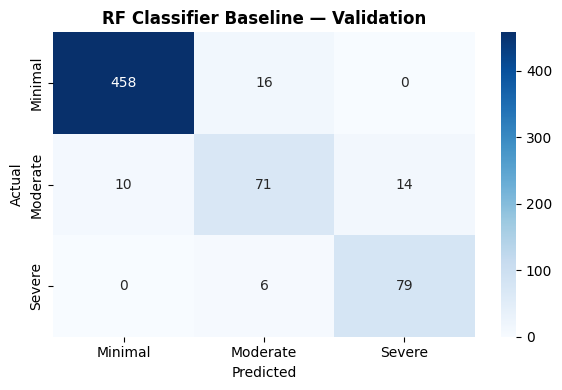

In [12]:
# Baseline: Random Forest Classifier

rf_cls_base = RandomForestClassifier(n_estimators=100, random_state=42)
rf_cls_base.fit(X_train, y_train_cls)

# Evaluate on validation set

print("--- Validation ---")
val_pred_cls_base, val_acc_base = eval_classifier(rf_cls_base, X_val, y_val_cls, "RF Classifier (Baseline) — Val")
plot_confusion(y_val_cls, val_pred_cls_base, "RF Classifier Baseline — Validation")

CV Accuracy (5-fold): 0.9643 ± 0.0052
CV Scores: [0.9607 0.9615 0.9615 0.9631 0.9746]

--- Validation ---

  RF Classifier (Improved) — Val — Accuracy: 0.9021
              precision    recall  f1-score   support

     Minimal       0.98      0.93      0.96       474
    Moderate       0.64      0.76      0.69        95
      Severe       0.83      0.91      0.87        85

    accuracy                           0.90       654
   macro avg       0.82      0.86      0.84       654
weighted avg       0.91      0.90      0.91       654



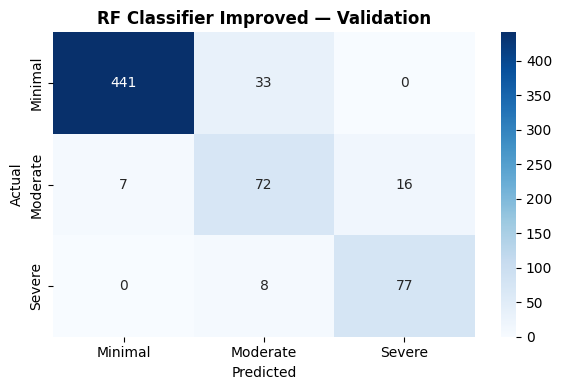

In [13]:
# Improved RF Classifier 

from sklearn.model_selection import cross_val_score, StratifiedKFold

rf_cls_improved = RandomForestClassifier(
    n_estimators=700,
    max_depth=14,
    min_samples_split=6,
    min_samples_leaf=2,
    max_features=0.6,
    class_weight='balanced',
    random_state=42
)
rf_cls_improved.fit(X_train, y_train_cls)

# Cross-validation on training set
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf_cls_improved, X_train, y_train_cls, cv=cv, scoring='accuracy')

print(f"CV Accuracy (5-fold): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"CV Scores: {cv_scores.round(4)}")

print("\n--- Validation ---")
val_pred_cls_imp, val_acc_imp = eval_classifier(rf_cls_improved, X_val, y_val_cls, "RF Classifier (Improved) — Val")
plot_confusion(y_val_cls, val_pred_cls_imp, "RF Classifier Improved — Validation")

XGB CV Accuracy (5-fold): 0.9772 ± 0.0064

--- Validation ---

  XGBoost Classifier — Val — Accuracy: 0.9083
              precision    recall  f1-score   support

     Minimal       0.98      0.95      0.96       474
    Moderate       0.68      0.73      0.70        95
      Severe       0.81      0.89      0.85        85

    accuracy                           0.91       654
   macro avg       0.82      0.86      0.84       654
weighted avg       0.91      0.91      0.91       654



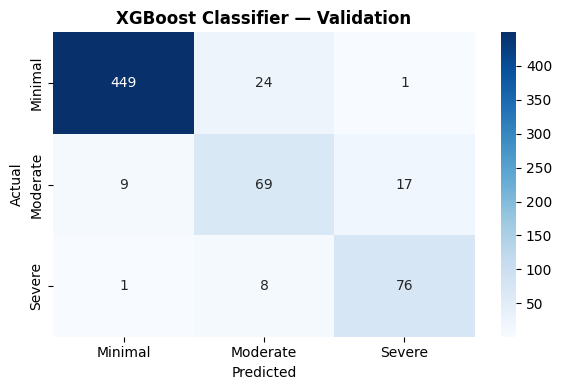

In [14]:
# Baseline: XG BoostClassifier

xgb_cls = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42
)
xgb_cls.fit(X_train, y_train_cls,
            eval_set=[(X_val, y_val_cls)],
            verbose=False)

# Cross-validation on training set

cv_scores_xgb = cross_val_score(xgb_cls, X_train, y_train_cls, cv=cv, scoring='accuracy')
print(f"XGB CV Accuracy (5-fold): {cv_scores_xgb.mean():.4f} ± {cv_scores_xgb.std():.4f}")

# Evaluate XGBoost model on validation set

print("\n--- Validation ---")
val_pred_xgb_cls, val_acc_xgb = eval_classifier(xgb_cls, X_val, y_val_cls, "XGBoost Classifier — Val")
plot_confusion(y_val_cls, val_pred_xgb_cls, "XGBoost Classifier — Validation")

XGB Improved CV Accuracy (5-fold): 0.9748 ± 0.0062

--- Validation ---

  XGBoost Classifier (Improved) — Val — Accuracy: 0.9052
              precision    recall  f1-score   support

     Minimal       0.98      0.94      0.96       474
    Moderate       0.67      0.74      0.70        95
      Severe       0.80      0.89      0.84        85

    accuracy                           0.91       654
   macro avg       0.82      0.86      0.84       654
weighted avg       0.91      0.91      0.91       654



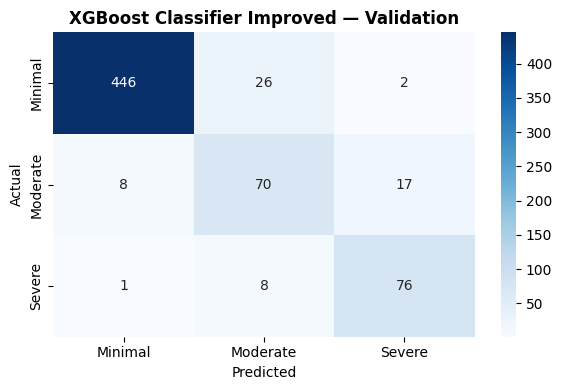

In [15]:
# Improved XGBoost Classifier with tuned hyperparameters

xgb_cls_improved = xgb.XGBClassifier(
    n_estimators=1000,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.85,
    colsample_bytree=0.85,
    min_child_weight=3,
    gamma=0.1,
    reg_lambda=1.2,
    reg_alpha=0.15,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42
)
xgb_cls_improved.fit(X_train, y_train_cls,
                     eval_set=[(X_val, y_val_cls)],
                     verbose=False)

cv_scores_xgb_imp = cross_val_score(xgb_cls_improved, X_train, y_train_cls,
                                     cv=cv, scoring='accuracy')
print(f"XGB Improved CV Accuracy (5-fold): {cv_scores_xgb_imp.mean():.4f} ± {cv_scores_xgb_imp.std():.4f}")

print("\n--- Validation ---")
val_pred_xgb_imp, val_acc_xgb_imp = eval_classifier(
    xgb_cls_improved, X_val, y_val_cls, "XGBoost Classifier (Improved) — Val"
)
plot_confusion(y_val_cls, val_pred_xgb_imp, "XGBoost Classifier Improved — Validation")

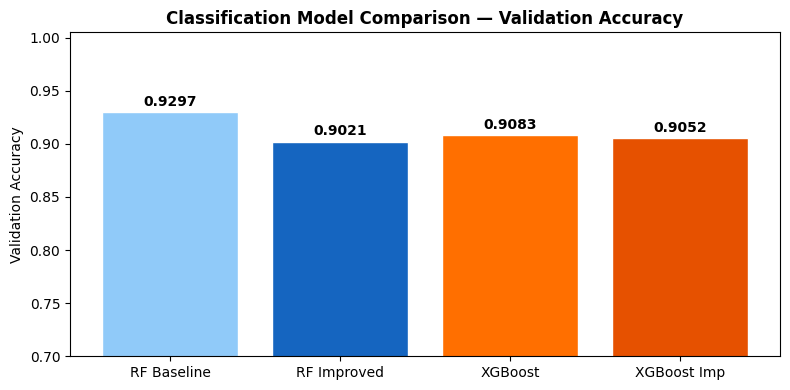

Best classifier: RF Baseline (0.9297)


In [16]:
# Summary of classification results

results_cls = {
    'RF Baseline':    accuracy_score(y_val_cls, rf_cls_base.predict(X_val)),
    'RF Improved':    accuracy_score(y_val_cls, rf_cls_improved.predict(X_val)),
    'XGBoost':        accuracy_score(y_val_cls, xgb_cls.predict(X_val)),
    'XGBoost Imp':    accuracy_score(y_val_cls, xgb_cls_improved.predict(X_val)),
}

plt.figure(figsize=(8, 4))
bars = plt.bar(results_cls.keys(), results_cls.values(),
               color=['#90CAF9','#1565C0','#FF6F00','#E65100'], edgecolor='white')
plt.ylim(0.7, 1.005)
plt.ylabel('Validation Accuracy')
plt.title('Classification Model Comparison — Validation Accuracy', fontweight='bold')
for bar, val in zip(bars, results_cls.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
             f'{val:.4f}', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

best_cls_name = max(results_cls, key=results_cls.get)
print(f"Best classifier: {best_cls_name} ({results_cls[best_cls_name]:.4f})")

# Part 2 — Regression (Predict Electricity Access %)

--- Validation ---

  RF Regressor (Baseline) — Val
  MAE  : 3.8058
  RMSE : 7.2455
  R²   : 0.9115


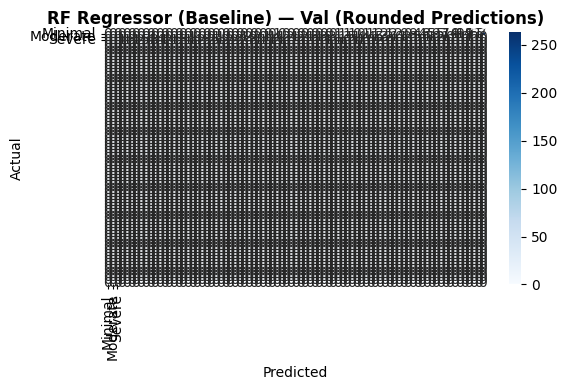

In [17]:
# Baseline: Random Forest Regressor
rf_reg_base = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg_base.fit(X_train, y_train_reg)

# Evaluate on validation set

print("--- Validation ---")
val_pred_reg_base, mae_b, rmse_b, r2_b = eval_regressor(rf_reg_base, X_val, y_val_reg, "RF Regressor (Baseline) — Val")
plot_confusion(y_val_cls, rf_reg_base.predict(X_val).round().astype(int), "RF Regressor (Baseline) — Val (Rounded Predictions)")

CV R² (5-fold): 0.7878 ± 0.0398

--- Validation ---

  RF Regressor (Improved) — Val
  MAE  : 3.9433
  RMSE : 6.9864
  R²   : 0.9178


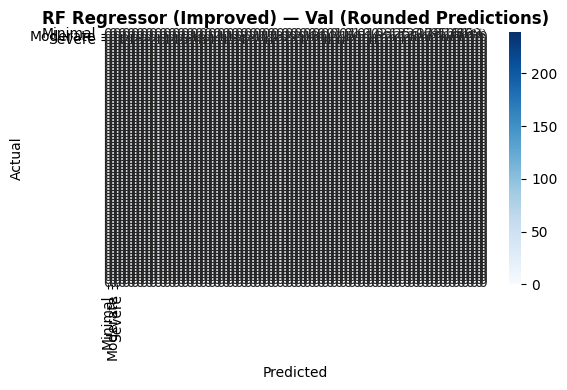

In [18]:
# Improved RF Regressor with hyperparameter tuning

from sklearn.model_selection import cross_val_score

rf_reg_improved = RandomForestRegressor(
    n_estimators=800,
    max_depth=16,
    min_samples_split=6,
    min_samples_leaf=2,
    max_features=0.6,
    bootstrap=True,
    random_state=42
)
rf_reg_improved.fit(X_train, y_train_reg)

# Cross-validation on training set

cv_reg = cross_val_score(rf_reg_improved, X_train, y_train_reg, cv=5, scoring='r2')
print(f"CV R² (5-fold): {cv_reg.mean():.4f} ± {cv_reg.std():.4f}")

# Evaluate improved regressor on validation set

print("\n--- Validation ---")
val_pred_reg_imp, mae_i, rmse_i, r2_i = eval_regressor(rf_reg_improved, X_val, y_val_reg, "RF Regressor (Improved) — Val")
plot_confusion(y_val_cls, rf_reg_improved.predict(X_val).round().astype(int), "RF Regressor (Improved) — Val (Rounded Predictions)")

XGB CV R² (5-fold): 0.7792 ± 0.0459

--- Validation ---

  XGBoost Regressor — Val
  MAE  : 4.0929
  RMSE : 7.4529
  R²   : 0.9064


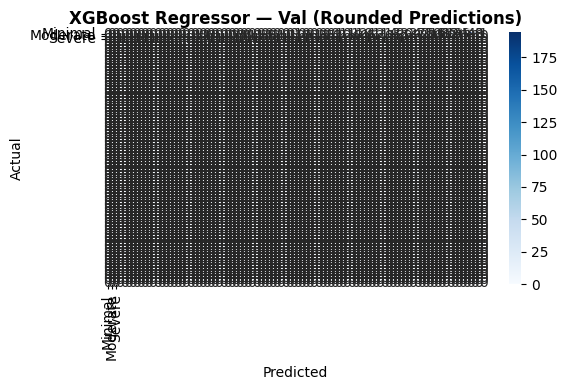

In [19]:
# Baseline: XG Boost Regressor

xgb_reg = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb_reg.fit(X_train, y_train_reg,
            eval_set=[(X_val, y_val_reg)],
            verbose=False)

# Cross-validation on training set

cv_reg_xgb = cross_val_score(xgb_reg, X_train, y_train_reg, cv=5, scoring='r2')
print(f"XGB CV R² (5-fold): {cv_reg_xgb.mean():.4f} ± {cv_reg_xgb.std():.4f}")

# Evaluate XGBoost model on validation set

print("\n--- Validation ---")
val_pred_reg_xgb, mae_x, rmse_x, r2_x = eval_regressor(xgb_reg, X_val, y_val_reg, "XGBoost Regressor — Val")
plot_confusion(y_val_cls, xgb_reg.predict(X_val).round().astype(int), "XGBoost Regressor — Val (Rounded Predictions)")

XGB Improved CV R² (5-fold): 0.7724 ± 0.0512

--- Validation ---

  XGBoost Regressor (Improved) — Val
  MAE  : 4.0365
  RMSE : 7.3058
  R²   : 0.9101


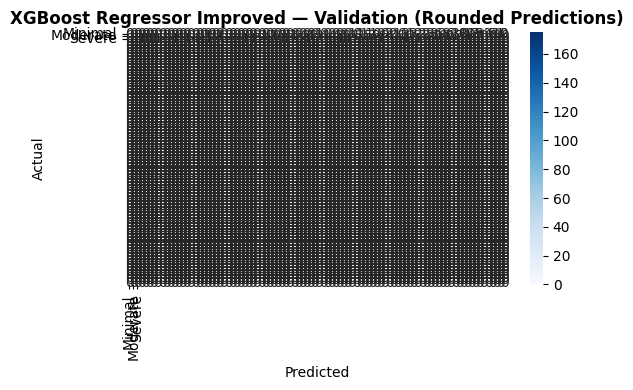

In [20]:
# Improved XGBoost Regressor

xgb_reg_improved = xgb.XGBRegressor(
    n_estimators=700,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.85,
    colsample_bytree=0.85,
    min_child_weight=2,
    gamma=0.05,
    reg_lambda=1.0,
    reg_alpha=0.1,
    random_state=42
)
xgb_reg_improved.fit(X_train, y_train_reg,
                     eval_set=[(X_val, y_val_reg)],
                     verbose=False)

cv_reg_xgb_imp = cross_val_score(xgb_reg_improved, X_train, y_train_reg,
                                  cv=5, scoring='r2')
print(f"XGB Improved CV R² (5-fold): {cv_reg_xgb_imp.mean():.4f} ± {cv_reg_xgb_imp.std():.4f}")

print("\n--- Validation ---")
val_pred_xgb_reg_imp, mae_xi, rmse_xi, r2_xi = eval_regressor(
    xgb_reg_improved, X_val, y_val_reg, "XGBoost Regressor (Improved) — Val"
)
plot_confusion(y_val_cls, xgb_reg_improved.predict(X_val).round().astype(int), "XGBoost Regressor Improved — Validation (Rounded Predictions)")

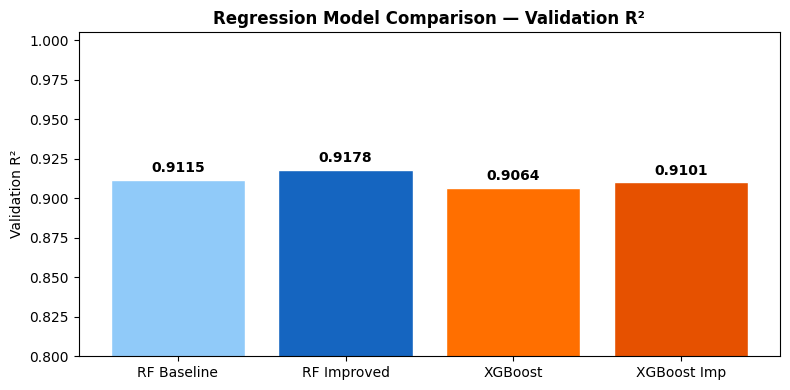

Best regressor: RF Improved (0.9178)


In [21]:
# Summary of regression results

results_reg = {
    'RF Baseline':  r2_b,
    'RF Improved':  r2_i,
    'XGBoost':      r2_x,
    'XGBoost Imp':  r2_xi,
}

plt.figure(figsize=(8, 4))
bars = plt.bar(results_reg.keys(), results_reg.values(),
               color=['#90CAF9','#1565C0','#FF6F00','#E65100'], edgecolor='white')
plt.ylim(0.8, 1.005)
plt.ylabel('Validation R²')
plt.title('Regression Model Comparison — Validation R²', fontweight='bold')
for bar, val in zip(bars, results_reg.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
             f'{val:.4f}', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

best_reg_name = max(results_reg, key=results_reg.get)
print(f"Best regressor: {best_reg_name} ({results_reg[best_reg_name]:.4f})")

# Feature Importance

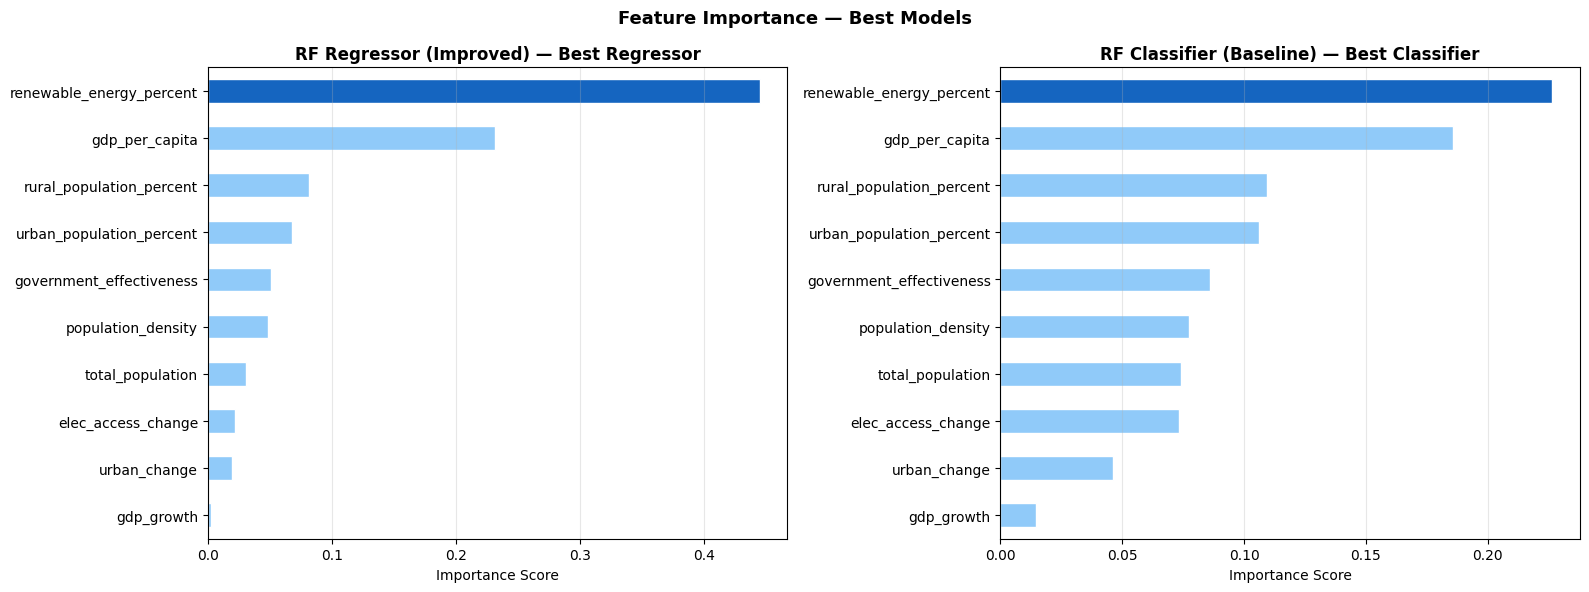

In [22]:
# Feature importance for best models

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Feature Importance — Best Models", fontsize=13, fontweight='bold')

for ax, model, title in zip(axes,
                             [rf_reg_improved, rf_cls_base],
                             ['RF Regressor (Improved) — Best Regressor',
                              'RF Classifier (Baseline) — Best Classifier']):
    importances = pd.Series(model.feature_importances_, index=FEATURES).sort_values()
    colors = ['#1565C0' if v == importances.max() else '#90CAF9' for v in importances]
    importances.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Importance Score')
    ax.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.show()